<div id="bg-slide">
    <center>
    <h1>DFT introduction #3 (short lecture)</h1>
<center>
<br>
<table>
  <tr>
      <td><p><h1>Team Rutgers</h1></p><p><h2>(Michele, Ezekiel & Valeria)</h2></p><p><h2>Rutgers University-Newark</h2></p></td> 
      <td><img src="../figures/logos/ASESMA_logo.png" width=300 height=300 /></td>
  </tr>
  <tr>
    <td></td>
    <td> https://prg.rutgers.edu</td>
  </tr>
</table>
<br>
<h3>Retrieve this presentation at:</h3>
<br>
<center>https://github.com/Quantum-MultiScale-Template/DFT-Intro/2026/miniASESMA_DFT_3.ipynb</center>

<br>

<center><h3> mini ASESMA 2026 -- Accra, Ghana -- June 15, 2026</h3></center>
</div>


# Goal of this lecture
 - Understand occupations (aufbau and smearing)
 - Understand and code the Self-Consistent Cycle (SCF)
 - Band structure / DOS

# Split into `N` groups

 - Assign number `1-N` to each student
 - Groups sit together
 - Possibly have 1 instructor per group

# The KS equations

$$-\frac{1}{2}\nabla^2 \phi_k(r) + v_s(r) \phi_k(r) = \varepsilon_k \phi_k(r)$$

### In discretized form

$$
\color{green}{\mathbb{HC}=\mathbb{SC\varepsilon}}
$$

### How can we solve it?
<br>
<center> <div class="alert alert-success"> <b><a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigh.html#scipy.linalg.eigh">Generalized eigenvalue problem</a></b></div></center>

# $\mathbb{H}$ depends on $v_s(r)$ which depends on $n(r)$

<center> <div class="alert alert-warning"> <b>What $n(r)$ should we use to evaluate $\mathbb{H}$?</b></div></center>

 - uniform density

 - sum of atomic densities (SAD), usually taken from the pseudopotential

<center><img src="../figures/science/sad.png" width=600 /></center>

<center> <div class="alert alert-danger"> <b>But this is only a guess...</b></div></center>

# The Self-Consistent Field (SCF) loop

<center><img src="../figures/science/scf.png" width=800 /></center>

# In QEpy and QE, the SCF is a basic workflow

 - QE handles it via the card `&control`

 - QEpy via the equivalent card in the options dictionary, like this:

In [1]:
qe_options = {}
qe_options['&control'] = {}
qe_options['&control']['calculation'] = 'scf'

# The SCF threshold

$\tau$ usually is in units of energy. Appropriate convergence conditions are

<center> <div class="alert alert-success">$$\int |n_{in}(r)-n_{out}(r)| dr < \tau$$</div></center>

<center> 
    <div class="alert alert-success">
        $$\int \frac{|n_{out}(r)-n_{in}(r)||n_{out}(r')-n_{in}(r')|}{|r-r'|} drdr' < \tau ~~\color{red}{\to ~~ \text{this is the condition adopted by QE}}$$
    </div>
</center>

# Challenge 1

- The electron density
 
Derive the equation for obtaining the electron density from the basis functions $\{\chi_k(r)\}$ and the wavefunction coefficients $\{C_{ki}\}$. Use the expression
 
 $$
 n(r) = \sum_k^N |\phi_k(r)|^2, \text{ assume for simplicity } \phi_k(r)\in \mathbb{R}
 $$
 
<center><img src="../figures/random/qr_poll3.1.png" width=500 height=300 /></center>

# Occupation numbers

The usual equation (remember $N$ is the number of electrons)
<center> 
    <div class="alert alert-success">$$  n(r) = \sum_k^N |\phi_k(r)|^2 \to \text{aufbau}$$
    </div>
</center>

For non-zero $T$ or for small gaps ($E_g\ll 1$ where the SCF can get confused):
<center>
    <div class="alert alert-warning">$$  n(r) = \sum_k f_k |\phi_k(r)|^2 \to \sum_k f_k = N$$</div>
    <br>
    where $f_k$ are called occupation numbers
</center>

For solids, the need for $k$-points often requires smearing:
<center> 
    <div class="alert alert-danger">$$  n(r) = \sum_k \sum_{\nu \in \text{FBZ}} f_{k\nu} |\phi_{k\nu}(r)|^2 \to \sum_{k\nu} f_{k\nu} = N$$
    </div>
</center>

# Challenge 2: what are these $f_k$?

- Code your own Fermi-Dirac smearing function to generate occupation numbers $\{f_k\}$ given orbital energies $\{\varepsilon_k\}$

Consider a set of eigenvalues, $\{\varepsilon_k\}$ coming from $\color{green}{\mathbb{HC}=\mathbb{SC\varepsilon}}$. Evaluate the Fermi-Dirac distribution and impose $\sum_k f_k = N$. <i>Feel free to use AI to help you code it.</i> Justify and explain your code to a TA.

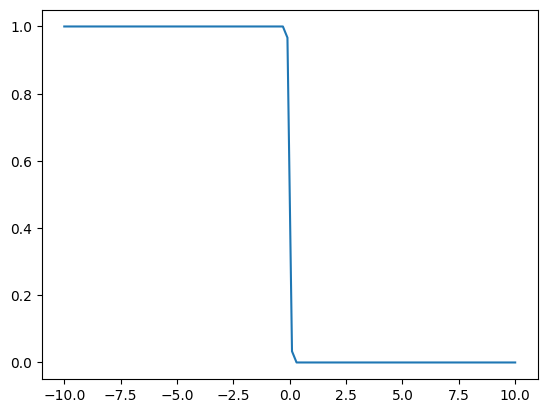

In [5]:
import matplotlib.pyplot as plt
import numpy as np
x=np.linspace(start=-10,stop=10,num=100)
tau = 0.03
plt.plot(x,(1+np.exp((x-0)/tau))**(-1))

<center> 
    <div class="alert alert-success">
        Now time for hands-on activities: "SCF with QEpy" (and have QE solve it!)
    </div>
</center>